In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
cols = ['engine_id','cycle','op1','op2','op3'] + \
       [f'sensor{i}' for i in range(1,22)]

df = pd.read_csv(
    "../data/raw/train_FD001.txt",
    sep = "\s+",
    header = None
)

df = df.iloc[:, :26]
df.columns = cols
df.head()

,engine_id,cycle,op1,op2,op3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor12,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [3]:
df.shape

(20631, 26)

In [4]:
df.engine_id.nunique()

100

In [5]:
df.groupby("engine_id")["cycle"].max().describe()


count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64

In [6]:
df[['op1','op2','op3']].describe()

,op1,op2,op3
count,20631.000000,20631.000000,20631.0
mean,-0.000009,0.000002,100.0
std,0.002187,0.000293,0.0
min,-0.008700,-0.000600,100.0
25%,-0.001500,-0.000200,100.0
50%,0.000000,0.000000,100.0
75%,0.001500,0.000300,100.0
max,0.008700,0.000600,100.0


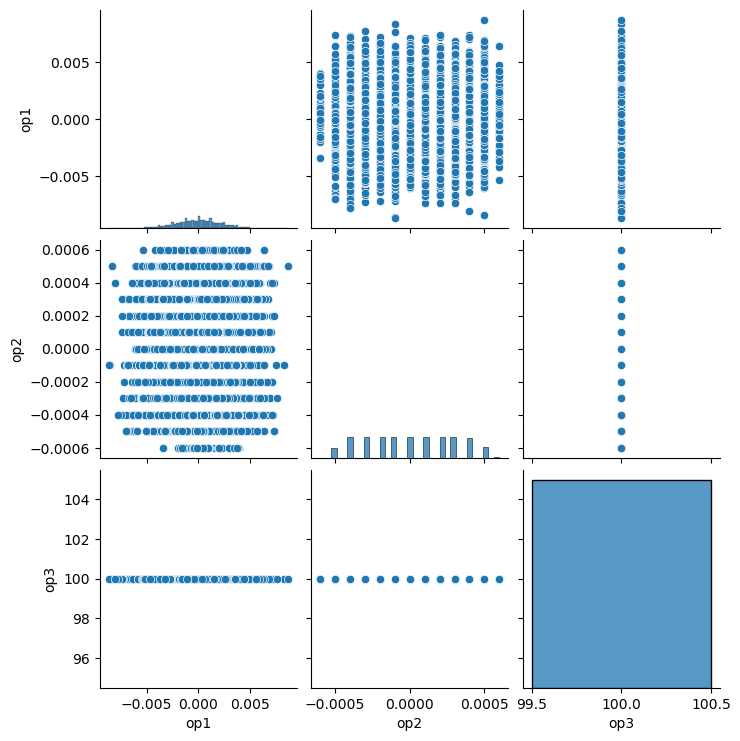

In [7]:
sns.pairplot(df[['op1','op2','op3']])

In [8]:
# this graph shows that only one opsetting is varying thus only 1 operating condition

df.nunique().sort_values()


sensor1         1
op3             1
sensor10        1
sensor5         1
sensor19        1
sensor16        1
sensor18        1
sensor6         2
sensor17       13
op2            13
sensor8        53
sensor13       56
engine_id     100
sensor20      120
op1           158
sensor11      159
sensor2       310
cycle         362
sensor12      427
sensor7       513
sensor15     1918
sensor3      3012
sensor4      4051
sensor21     4745
sensor14     6078
sensor9      6403
dtype: int64

<Axes: title={'center': 'Sensor variance'}>

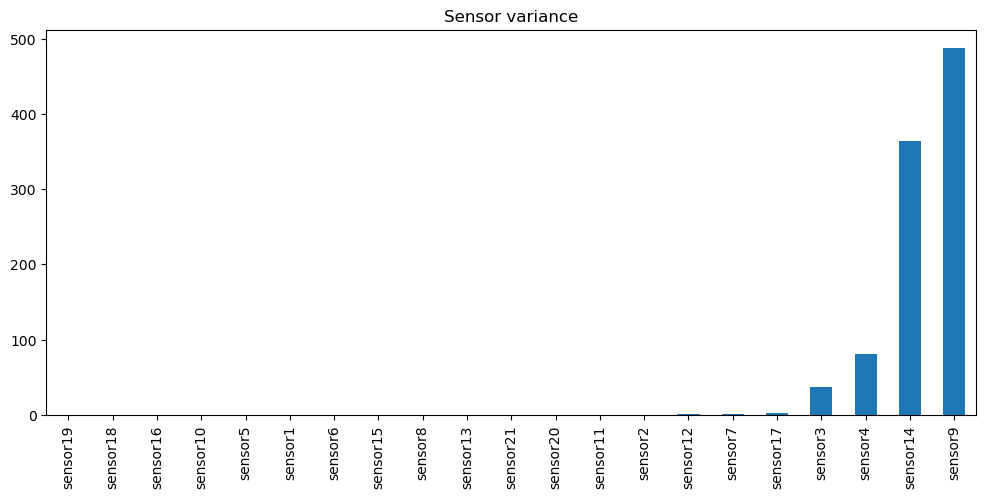

In [9]:
#sensor variance
sensor_cols = [col for col in df.columns if "sensor" in col]
df[sensor_cols].var().sort_values().plot(
    kind = "bar",
    figsize=(12,5),
    title = "Sensor variance"
)

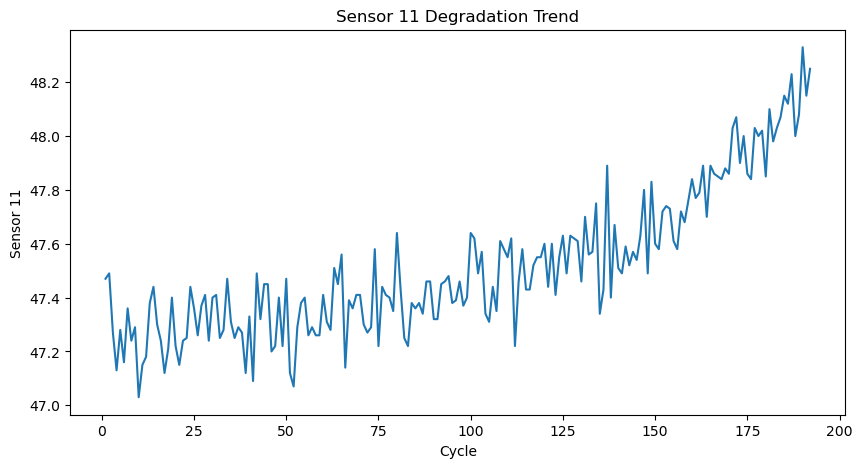

In [10]:
#VISUALIZING THE DEGRADATION TREND

engine1 = df[df.engine_id == 1]
plt.figure(figsize=(10,5))
plt.plot(engine1.cycle, engine1.sensor11)
plt.xlabel("Cycle")
plt.ylabel("Sensor 11")
plt.title("Sensor 11 Degradation Trend")
plt.show()

<Axes: >

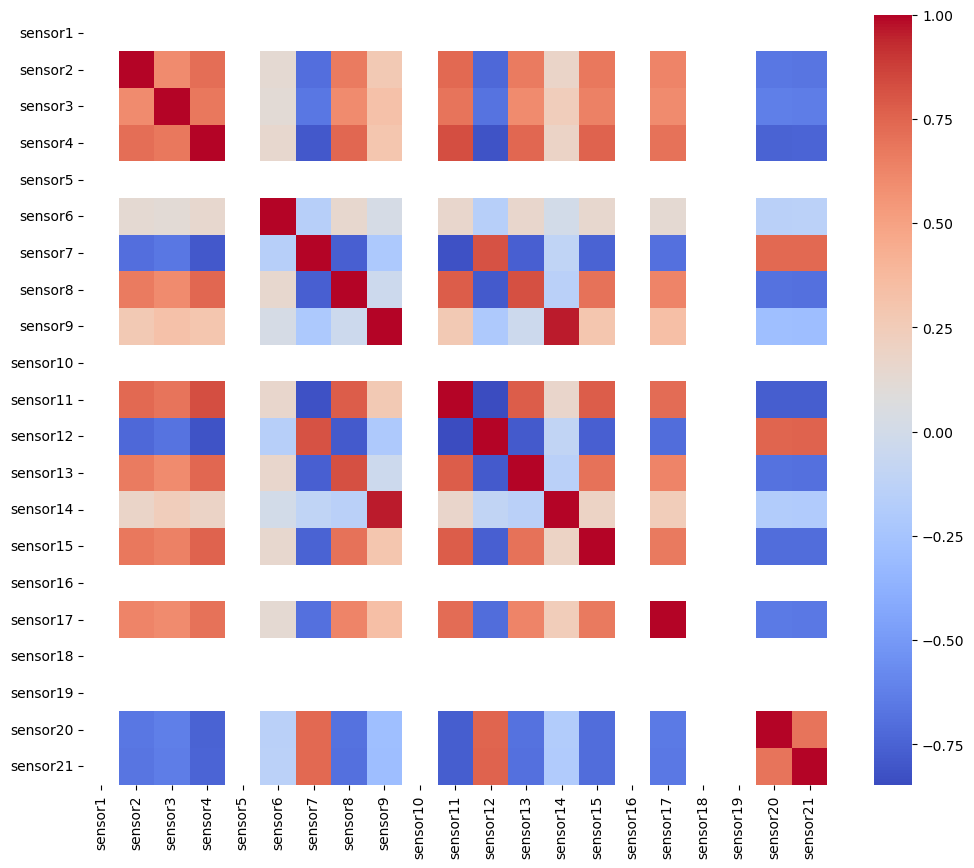

In [11]:
corr = df[sensor_cols].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="coolwarm")


In [12]:
max_cycle = df.groupby("engine_id")["cycle"].max()

df["RUL"] = df.apply(
    lambda row: max_cycle[row.engine_id] - row.cycle,
    axis=1
)


Text(0, 0.5, 'RUL')

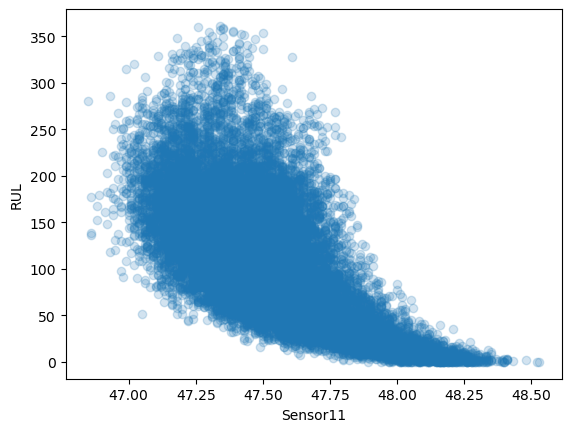

In [13]:
plt.scatter(df.sensor11, df.RUL, alpha=0.2)
plt.xlabel("Sensor11")
plt.ylabel("RUL")
